In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_test_2014_05_12.csv" "/content/master_long_hourly_test_2014_05_12.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_train_2012_2013.csv" "/content/master_long_hourly_train_2012_2013.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/master_long_hourly_validation_2014_01_04.csv" "/content/master_long_hourly_validation_2014_01_04.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/calendar_features_hourly.csv" "/content/calendar_features_hourly.csv"
!cp "/content/drive/MyDrive/Forecasting/project1/data/user_cluster_mapping.csv" "/content/user_cluster_mapping.csv"

In [3]:
!pip install statsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 18.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 27.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 22.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 16.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.7 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [4]:
from pathlib import Path

# Input files — produced by preprocessing + data-split teammate
TRAIN_PATH    = "/content/master_long_hourly_train_2012_2013.csv"
VAL_PATH      = "/content/master_long_hourly_validation_2014_01_04.csv"
TEST_PATH     = "/content/master_long_hourly_test_2014_05_12.csv"
CALENDAR_PATH = "/content/calendar_features_hourly.csv"
MAPPING_PATH  = "/content/user_cluster_mapping.csv"   # cluster assignments

# Output
SELECTED_CLIENTS_PATH = Path("selected_clients_sarimax.csv")

# Sampling
RANDOM_SEED = 42

# Model
SEASON_LENGTH  = 24   # hourly data → daily seasonality
LOOKBACK_HOURS = 672  # 4 weeks lookback
MODEL_DIR = Path("models")
MODEL_DIR.mkdir(exist_ok=True)

In [5]:
# IMPORTS
import warnings
warnings.filterwarnings('ignore')

import joblib
import numpy as np
import pandas as pd
from statsforecast import StatsForecast
from statsforecast.models import ARIMA, AutoARIMA
import matplotlib.pyplot as plt

In [6]:
# ── SAMPLE CLIENTS ───────────────────────────────────────────────────────────
# Read only the client_id column to avoid loading the full file
train_ids = pd.read_csv(TRAIN_PATH, usecols=["client_id"])
all_clients = train_ids["client_id"].unique()

# rng = np.random.default_rng(RANDOM_SEED)
# selected = sorted(rng.choice(all_clients, size=N_CLIENTS, replace=False).tolist())
selected = sorted(all_clients.tolist()) # Use all clients

print(f"Selected {len(selected)} clients (ALL)")

# Save so teammates can use the same clients
pd.DataFrame({"client_id": selected}).to_csv(SELECTED_CLIENTS_PATH, index=False)
print(f"Saved client list → {SELECTED_CLIENTS_PATH}")

Selected 156 clients (ALL)
Saved client list → selected_clients_sarimax.csv


In [7]:
# ── PREPARE DATA ─────────────────────────────────────────────────────────────
# Cyclic encodings (sin/cos) capture periodicity without ordinality.
# is_weekend adds a structural break between weekdays and weekends.
# Skipping raw integer columns (hour, day_of_week, etc.) — cyclic versions are better for SARIMAX.
EXOG_COLS = ["hour_sin", "hour_cos", "dow_sin", "dow_cos", "is_weekend", "month_sin", "month_cos"]

calendar = pd.read_csv(CALENDAR_PATH, parse_dates=["timestamp"])


def load_split(path, clients, calendar, exog_cols):
    df = pd.read_csv(path, parse_dates=["timestamp"])
    df = df[df["client_id"].isin(clients)].copy()
    df = df.merge(calendar[["timestamp"] + exog_cols], on="timestamp", how="left")
    # StatsForecast expects: unique_id, ds, y
    df = df.rename(columns={"client_id": "unique_id", "timestamp": "ds"})
    return df.sort_values(["unique_id", "ds"]).reset_index(drop=True)


def apply_lookback(df, hours):
    """Keep only the last `hours` rows per client."""
    return (df.groupby("unique_id", group_keys=False)
              .tail(hours)
              .reset_index(drop=True))


train = load_split(TRAIN_PATH, selected, calendar, EXOG_COLS)
val   = load_split(VAL_PATH,   selected, calendar, EXOG_COLS)
test  = load_split(TEST_PATH,  selected, calendar, EXOG_COLS)

# Apply 4-week lookback: train on the most recent 672 hours per client
train = apply_lookback(train, LOOKBACK_HOURS)

print(f"train : {train.shape}  {train['ds'].min()} → {train['ds'].max()}")
print(f"val   : {val.shape}    {val['ds'].min()} → {val['ds'].max()}")
print(f"test  : {test.shape}   {test['ds'].min()} → {test['ds'].max()}")

train : (104832, 10)  2013-12-04 00:00:00 → 2013-12-31 23:00:00
val   : (445536, 10)    2014-01-01 00:00:00 → 2014-04-30 23:00:00
test  : (913536, 10)   2014-05-01 00:00:00 → 2014-12-31 23:00:00


In [8]:
# CLUSTER AGGREGATION
# Load cluster assignments produced by the clustering pipeline
mapping       = pd.read_csv(MAPPING_PATH)
cluster_map   = mapping[mapping["cluster_id"] != -1].set_index("user_id")["cluster_id"]
outlier_users = mapping[mapping["cluster_id"] == -1]["user_id"].tolist()


def aggregate_to_clusters(df, cluster_map, outlier_users, exog_cols):
    """Average all users in a cluster into one series per cluster.
    Outlier users (cluster_id == -1) are kept as individual series.
    """
    rows = []
    for cluster_id, users in cluster_map.groupby(cluster_map):
        cluster_users = users.index.tolist()
        cluster_df = df[df["unique_id"].isin(cluster_users)]
        agg = (
            cluster_df
            .groupby("ds")[["y"] + exog_cols]
            .mean()
            .reset_index()
        )
        agg["unique_id"] = f"cluster_{int(cluster_id)}"
        rows.append(agg)
    for user in outlier_users:
        rows.append(df[df["unique_id"] == user].copy())
    return (
        pd.concat(rows, ignore_index=True)
        .sort_values(["unique_id", "ds"])
        .reset_index(drop=True)
    )


# Compute per-user scale factor relative to its cluster mean (training data only)
user_means = train.groupby("unique_id")["y"].mean()
user_proportions = {}
for cluster_id, users in cluster_map.groupby(cluster_map):
    cluster_users = users.index.tolist()
    cluster_mean  = user_means[cluster_users].mean()
    for user in cluster_users:
        user_proportions[user] = float(user_means[user] / cluster_mean)
for user in outlier_users:
    user_proportions[user] = 1.0  # outliers are their own series

train_agg = aggregate_to_clusters(train, cluster_map, outlier_users, EXOG_COLS)
val_agg   = aggregate_to_clusters(val,   cluster_map, outlier_users, EXOG_COLS)
test_agg  = aggregate_to_clusters(test,  cluster_map, outlier_users, EXOG_COLS)

print(f"Training on {train_agg['unique_id'].nunique()} series: {sorted(train_agg['unique_id'].unique())}")

Training on 10 series: ['MT_124', 'MT_132', 'MT_156', 'MT_158', 'MT_159', 'MT_161', 'MT_162', 'MT_163', 'cluster_0', 'cluster_1']


In [9]:
# EVALUATION METRICS
def compute_metrics(df, target_col="y", pred_col="ARIMA"):
    y    = df[target_col].values
    yhat = df[pred_col].values
    pos  = y > 0
    mse  = np.mean((y - yhat) ** 2)
    mae  = np.mean(np.abs(y - yhat))
    mape = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")
    wape = np.sum(np.abs(y - yhat)) / np.sum(np.abs(y))
    return {"MSE": round(mse, 4), "MAE": round(mae, 4), "MAPE": round(mape, 4), "WAPE": round(wape, 4)}


def per_client_metrics(df, target_col="y", pred_col="ARIMA"):
    rows = []
    for uid, grp in df.groupby("unique_id"):
        rows.append({"client_id": uid, **compute_metrics(grp, target_col, pred_col)})
    rows.append({"client_id": "OVERALL", **compute_metrics(df, target_col, pred_col)})
    return pd.DataFrame(rows)


# DISAGGREGATE cluster forecasts back to individual users
def disaggregate(preds_df, user_proportions, cluster_map, outlier_users, pred_col):
    """Scale cluster-level forecasts back to individual user level."""
    rows = []
    for cluster_id, users in cluster_map.groupby(cluster_map):
        cluster_uid = f"cluster_{int(cluster_id)}"
        cluster_fc  = preds_df[preds_df["unique_id"] == cluster_uid][["ds", pred_col]].copy()
        for user in users.index:
            user_fc = cluster_fc.copy()
            user_fc[pred_col] = user_fc[pred_col] * user_proportions[user]
            user_fc["unique_id"] = user
            rows.append(user_fc)
    for user in outlier_users:
        rows.append(preds_df[preds_df["unique_id"] == user][["unique_id", "ds", pred_col]].copy())
    return pd.concat(rows, ignore_index=True)

In [10]:
# ── TRAIN SARIMAX (one StatsForecast per cluster / outlier series) ────────────
sf_models = {}
for uid in sorted(train_agg["unique_id"].unique()):
    sub     = train_agg[train_agg["unique_id"] == uid][["unique_id", "ds", "y"] + EXOG_COLS]
    model_i = AutoARIMA(season_length=SEASON_LENGTH, approximation=True, stepwise=True)
    sf_i    = StatsForecast(models=[model_i], freq="h", n_jobs=1)
    sf_i.fit(sub)
    joblib.dump(sf_i, MODEL_DIR / f"sarimax_val_{uid}.joblib")
    sf_models[uid] = sf_i
    print(f'  Fitted and saved: sarimax_val_{uid}.joblib')

print(f"Training complete. {len(sf_models)} models saved → {MODEL_DIR}/")

  Fitted and saved: sarimax_val_MT_124.joblib
  Fitted and saved: sarimax_val_MT_132.joblib
  Fitted and saved: sarimax_val_MT_156.joblib
  Fitted and saved: sarimax_val_MT_158.joblib
  Fitted and saved: sarimax_val_MT_159.joblib
  Fitted and saved: sarimax_val_MT_161.joblib
  Fitted and saved: sarimax_val_MT_162.joblib
  Fitted and saved: sarimax_val_MT_163.joblib
  Fitted and saved: sarimax_val_cluster_0.joblib
  Fitted and saved: sarimax_val_cluster_1.joblib
Training complete. 10 models saved → models/


In [11]:
# ── VALIDATION FORECAST ───────────────────────────────────────────────────────
val_preds_list = []
for uid, sf_i in sf_models.items():
    sub_val = val_agg[val_agg["unique_id"] == uid]
    preds_i = sf_i.predict(
        h=sub_val["ds"].nunique(),
        X_df=sub_val[["unique_id", "ds"] + EXOG_COLS]
    )
    val_preds_list.append(preds_i)

val_preds_agg = pd.concat(val_preds_list, ignore_index=True)
val_preds     = disaggregate(val_preds_agg, user_proportions, cluster_map, outlier_users, "AutoARIMA")
val_eval      = val[["unique_id", "ds", "y"]].merge(val_preds, on=["unique_id", "ds"])

print(val_eval.head())

  unique_id                  ds          y   AutoARIMA
0    MT_124 2014-01-01 00:00:00  95.693780  132.197285
1    MT_124 2014-01-01 01:00:00  83.732056  122.075237
2    MT_124 2014-01-01 02:00:00  82.535890  106.343234
3    MT_124 2014-01-01 03:00:00  82.535890   71.045445
4    MT_124 2014-01-01 04:00:00  63.397133   31.193867


In [12]:
# 1. Training Metrics (In-Sample)
train_preds_list = []
for uid, sf_i in sf_models.items():
    fitted_model = sf_i.fitted_[0, 0]   # one series per sf_i → index [0, 0]
    client_train = train_agg[train_agg["unique_id"] == uid].copy()

    in_sample_preds = fitted_model.predict_in_sample()
    if isinstance(in_sample_preds, dict):
        preds = in_sample_preds.get("mean", in_sample_preds.get("fitted", list(in_sample_preds.values())[0]))
    else:
        preds = in_sample_preds

    train_preds_list.append(pd.DataFrame({
        "unique_id": [uid] * len(client_train),
        "ds":        client_train["ds"].values,
        "AutoARIMA": preds,
    }))

train_preds_agg = pd.concat(train_preds_list, ignore_index=True)
train_preds     = disaggregate(train_preds_agg, user_proportions, cluster_map, outlier_users, "AutoARIMA")
train_eval      = train[["unique_id", "ds", "y"]].merge(train_preds, on=["unique_id", "ds"], how="left")

train_metrics = per_client_metrics(train_eval.dropna(), pred_col="AutoARIMA")
print("── Training Metrics (In-Sample) ──")
print(train_metrics.head(5).to_string(index=False))
print("...")
print(train_metrics.tail(1).to_string(index=False))
print("\n")

# 2. Validation Metrics (Out-of-Sample)
val_metrics = per_client_metrics(val_eval, pred_col="AutoARIMA")
print("── Validation Metrics (Out-of-Sample) ──")
print(val_metrics.head(5).to_string(index=False))
print("...")
print(val_metrics.tail(1).to_string(index=False))

── Training Metrics (In-Sample) ──
client_id      MSE     MAE    MAPE   WAPE
   MT_124 918.4121 21.8408 10.6287 0.0816
   MT_132  69.6918  4.8397 25.8152 0.2979
   MT_156  82.3269  6.3680 11.0202 0.0948
   MT_158 326.4842 12.4478 26.3229 0.1673
   MT_159 176.1831  8.1321 23.4868 0.1325
...
client_id        MSE     MAE    MAPE   WAPE
  OVERALL 33237.2089 53.7121 49.4883 0.0864


── Validation Metrics (Out-of-Sample) ──
client_id        MSE      MAE     MAPE   WAPE
   MT_124 10790.5017  82.5459  36.5176 0.3049
   MT_132   179.5037  11.0396  30.7848 0.6456
   MT_156  1833.2875  36.2980  39.9233 0.4446
   MT_158 23073.7712 144.8790 248.7338 1.9635
   MT_159  3001.2661  46.8198 152.7243 0.9196
...
client_id         MSE      MAE   MAPE   WAPE
  OVERALL 149499.6529 103.5868 19.329 0.1689


In [13]:
# ── TEST EVALUATION ───────────────────────────────────────────────────────────
# Retrain on train+val (with lookback), then predict on the held-out test set
train_val     = pd.concat([train, val], ignore_index=True).sort_values(["unique_id", "ds"])
train_val     = apply_lookback(train_val, LOOKBACK_HOURS)
train_val_agg = aggregate_to_clusters(train_val, cluster_map, outlier_users, EXOG_COLS)

sf_final_models = {}
for uid in sorted(train_val_agg["unique_id"].unique()):
    sub     = train_val_agg[train_val_agg["unique_id"] == uid][["unique_id", "ds", "y"] + EXOG_COLS]
    model_i = AutoARIMA(season_length=SEASON_LENGTH, approximation=True, stepwise=True)
    sf_i    = StatsForecast(models=[model_i], freq="h", n_jobs=1)
    sf_i.fit(sub)
    joblib.dump(sf_i, MODEL_DIR / f"sarimax_final_{uid}.joblib")
    sf_final_models[uid] = sf_i
    print(f'  Fitted and saved: sarimax_final_{uid}.joblib')

test_preds_list = []
for uid, sf_i in sf_final_models.items():
    sub_test = test_agg[test_agg["unique_id"] == uid]
    preds_i  = sf_i.predict(
        h=sub_test["ds"].nunique(),
        X_df=sub_test[["unique_id", "ds"] + EXOG_COLS]
    )
    test_preds_list.append(preds_i)

test_preds_agg = pd.concat(test_preds_list, ignore_index=True)
test_preds     = disaggregate(test_preds_agg, user_proportions, cluster_map, outlier_users, "AutoARIMA")
test_eval      = test[["unique_id", "ds", "y"]].merge(test_preds, on=["unique_id", "ds"])

test_metrics = per_client_metrics(test_eval, pred_col="AutoARIMA")
print("── Test metrics ──")
print(test_metrics.to_string(index=False))

  Fitted and saved: sarimax_final_MT_124.joblib
  Fitted and saved: sarimax_final_MT_132.joblib
  Fitted and saved: sarimax_final_MT_156.joblib
  Fitted and saved: sarimax_final_MT_158.joblib
  Fitted and saved: sarimax_final_MT_159.joblib
  Fitted and saved: sarimax_final_MT_161.joblib
  Fitted and saved: sarimax_final_MT_162.joblib
  Fitted and saved: sarimax_final_MT_163.joblib
  Fitted and saved: sarimax_final_cluster_0.joblib
  Fitted and saved: sarimax_final_cluster_1.joblib
── Test metrics ──
client_id          MSE       MAE     MAPE   WAPE
   MT_124 3.500138e+03   43.3344  16.8026 0.1443
   MT_132 8.258370e+02   23.4156 104.0567 1.5472
   MT_156 7.060933e+02   19.2063  33.5389 0.2159
   MT_158 1.598990e+03   32.8845  72.2688 0.4196
   MT_159 2.423343e+03   36.2883  89.8664 0.8475
   MT_161 4.907087e+06 1993.1125 126.6036 1.2711
   MT_162 2.437992e+04  125.5413  94.9424 0.4631
   MT_163 1.241058e+07 3215.3950 131.1517 1.2859
   MT_166 4.163218e+04  168.9866  14.1462 0.1308
   MT

In [14]:
# TEST PERIOD EVALUATION — MAPE per period + box plot of per-user errors

PRED_COL = "AutoARIMA"

# Equal-size test periods (1464 hours = 61 days each)
TEST_PERIODS = [
    {"period_id": 1, "label": "Late Spring",     "start": "2014-05-01", "end": "2014-06-30"},
    {"period_id": 2, "label": "Summer",           "start": "2014-07-01", "end": "2014-08-30"},
    {"period_id": 3, "label": "Early Fall",       "start": "2014-08-31", "end": "2014-10-31"},
    {"period_id": 4, "label": "Late Fall/Winter", "start": "2014-11-01", "end": "2014-12-31"},
]


def _period_mask(df, start, end):
    s = pd.Timestamp(start)
    e = pd.Timestamp(end) + pd.Timedelta(hours=23)
    return (df["ds"] >= s) & (df["ds"] <= e)


def period_mape(df, start, end, pred_col):
    """Overall MAPE (0-100) for a time period across all users."""
    sub = df[_period_mask(df, start, end)]
    y, yhat = sub["y"].values, sub[pred_col].values
    pos = y > 0
    return float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")


def per_user_mapes_period(df, start, end, pred_col):
    """List of per-user MAPEs (0-100) for a time period (used for box plot)."""
    sub = df[_period_mask(df, start, end)]
    mapes = []
    for _, grp in sub.groupby("unique_id"):
        y, yhat = grp["y"].values, grp[pred_col].values
        pos = y > 0
        if pos.sum() > 0:
            mapes.append(float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100))
    return mapes

In [15]:
# ── MAPE table ────────────────────────────────────────────────────────────────
print(f"{'P':<4} {'Label':<20} {'Dates':<28} {'MAPE (0-100)':>12}")
print("─" * 68)
box_data, box_labels = [], []
for p in TEST_PERIODS:
    mape  = period_mape(test_eval, p["start"], p["end"], PRED_COL)
    mapes = per_user_mapes_period(test_eval, p["start"], p["end"], PRED_COL)
    box_data.append(mapes)
    box_labels.append(f"P{p['period_id']}: {p['label']}\n{p['start']} – {p['end']}")
    print(f"  {p['period_id']}  {p['label']:<20} {p['start']} – {p['end']}   {mape:>8.2f}%")

P    Label                Dates                        MAPE (0-100)
────────────────────────────────────────────────────────────────────
  1  Late Spring          2014-05-01 – 2014-06-30      14.93%
  2  Summer               2014-07-01 – 2014-08-30      18.19%
  3  Early Fall           2014-08-31 – 2014-10-31      18.44%
  4  Late Fall/Winter     2014-11-01 – 2014-12-31      19.00%


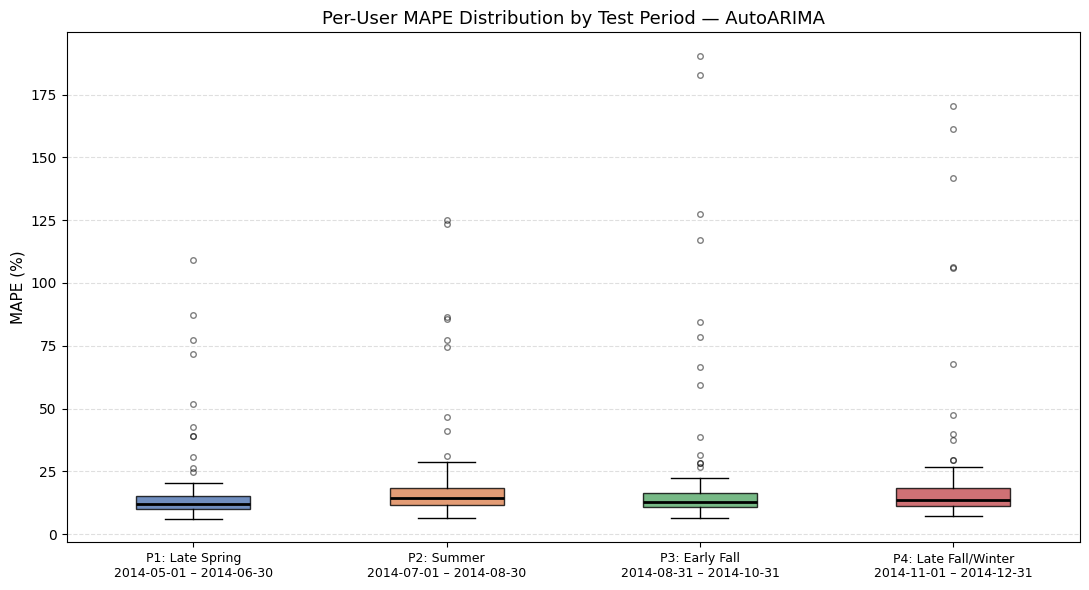

In [16]:
# ── Box plot ──────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(11, 6))
bp = ax.boxplot(
    box_data,
    patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
)
colors = ["#4C72B0", "#DD8452", "#55A868", "#C44E52"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)

ax.set_xticks(range(1, len(TEST_PERIODS) + 1))
ax.set_xticklabels(box_labels, fontsize=9)
ax.set_ylabel("MAPE (%)", fontsize=11)
ax.set_title(f"Per-User MAPE Distribution by Test Period — {PRED_COL}", fontsize=13)
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(MODEL_DIR / f"test_period_boxplot_{PRED_COL.lower()}.png", dpi=150)
plt.show()

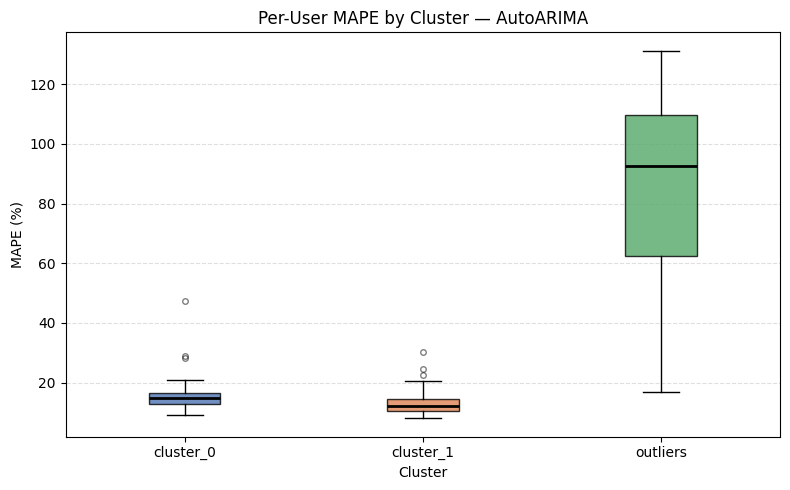

In [17]:
# BOX PLOT: Per-User MAPE by Cluster — SARIMAX

# Map each user to its cluster label
user_to_cluster = {}
for cluster_id, users in cluster_map.groupby(cluster_map):
    for user in users.index:
        user_to_cluster[user] = f"cluster_{int(cluster_id)}"
for user in outlier_users:
    user_to_cluster[user] = "outliers"

# Compute per-user MAPE over the full test period
per_user_mapes = {}
for uid, grp in test_eval.groupby("unique_id"):
    y, yhat = grp["y"].values, grp[PRED_COL].values
    pos = y > 0
    mape_u = float(np.mean(np.abs((y[pos] - yhat[pos]) / y[pos])) * 100) if pos.sum() > 0 else float("nan")
    per_user_mapes[uid] = mape_u

# Group MAPEs by cluster
cluster_labels = sorted(set(user_to_cluster.values()))
box_data = []
for label in cluster_labels:
    users_in = [u for u, c in user_to_cluster.items() if c == label]
    mapes    = [per_user_mapes[u] for u in users_in
                if u in per_user_mapes and not np.isnan(per_user_mapes[u])]
    box_data.append(mapes)

fig, ax = plt.subplots(figsize=(8, 5))
bp = ax.boxplot(
    box_data, labels=cluster_labels, patch_artist=True,
    medianprops=dict(color="black", linewidth=2),
    flierprops=dict(marker="o", markersize=4, alpha=0.5),
)
colors = ["#4C72B0", "#DD8452", "#55A868"]
for patch, color in zip(bp["boxes"], colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.8)
ax.set_title(f"Per-User MAPE by Cluster — {PRED_COL}")
ax.set_ylabel("MAPE (%)")
ax.set_xlabel("Cluster")
ax.grid(axis="y", linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(MODEL_DIR / f"cluster_boxplot_{PRED_COL.lower()}.png", dpi=150)
plt.show()

In [18]:
!zip -r SARIMAX_models.zip models/

from google.colab import files
files.download('SARIMAX_models.zip')

  adding: models/ (stored 0%)
  adding: models/sarimax_final_MT_163.joblib (deflated 75%)
  adding: models/sarimax_final_MT_162.joblib (deflated 69%)
  adding: models/sarimax_final_MT_132.joblib (deflated 91%)
  adding: models/sarimax_val_MT_124.joblib (deflated 66%)
  adding: models/sarimax_final_cluster_0.joblib (deflated 71%)
  adding: models/sarimax_final_MT_124.joblib (deflated 66%)
  adding: models/sarimax_val_cluster_1.joblib (deflated 63%)
  adding: models/sarimax_final_MT_158.joblib (deflated 75%)
  adding: models/test_period_boxplot_autoarima.png (deflated 24%)
  adding: models/sarimax_val_MT_132.joblib (deflated 79%)
  adding: models/sarimax_val_MT_158.joblib (deflated 68%)
  adding: models/sarimax_val_MT_156.joblib (deflated 71%)
  adding: models/sarimax_final_MT_159.joblib (deflated 89%)
  adding: models/sarimax_val_cluster_0.joblib (deflated 64%)
  adding: models/sarimax_val_MT_161.joblib (deflated 83%)
  adding: models/sarimax_val_MT_162.joblib (deflated 82%)
  adding: m

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>